In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')



In [2]:
# The data set is from cardekho company and it is a dataset of used cars.
df = pd.read_csv("cardekho_dataset.csv")
df = df.drop(columns=["Unnamed: 0"])
df

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
15406,Hyundai i10,Hyundai,i10,9,10723,Dealer,Petrol,Manual,19.81,1086,68.05,5,250000
15407,Maruti Ertiga,Maruti,Ertiga,2,18000,Dealer,Petrol,Manual,17.50,1373,91.10,7,925000
15408,Skoda Rapid,Skoda,Rapid,6,67000,Dealer,Diesel,Manual,21.14,1498,103.52,5,425000
15409,Mahindra XUV500,Mahindra,XUV500,5,3800000,Dealer,Diesel,Manual,16.00,2179,140.00,7,1225000


In [3]:
columns = df.columns
columns
df.info()
df.describe()
df.isnull().sum()
df.duplicated().sum()
df.drop_duplicates(inplace=True)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15411 entries, 0 to 15410
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   car_name           15411 non-null  object 
 1   brand              15411 non-null  object 
 2   model              15411 non-null  object 
 3   vehicle_age        15411 non-null  int64  
 4   km_driven          15411 non-null  int64  
 5   seller_type        15411 non-null  object 
 6   fuel_type          15411 non-null  object 
 7   transmission_type  15411 non-null  object 
 8   mileage            15411 non-null  float64
 9   engine             15411 non-null  int64  
 10  max_power          15411 non-null  float64
 11  seats              15411 non-null  int64  
 12  selling_price      15411 non-null  int64  
dtypes: float64(2), int64(5), object(6)
memory usage: 1.5+ MB


About the dataset:

The dataset contains information about cars, including their features and prices.
The dataset contains 15,411 rows and 13 columns with the following features: 

car_name: Car's Full name, which includes brand and specific model name.

brand: Brand Name of the particular car.

model: Exact model name of the car of a particular brand.

seller_type: Which Type of seller is selling the used car

fuel_type: Fuel used in the used car, which was put up on sale.

km_driven: The number of kilometers the car has driven.

transmission_type: Transmission used in the used car, which was put on sale.

vehicle_age: The count of years since car was bought.

mileage: It is the number of kilometer the car runs per litre.

engine: It is the engine capacity in cc(cubic centimeters)

max_power: Max power it produces in BHP.

seats: Total number of seats in car.

selling_price: The sale price which was put up on website.

    


In [4]:
# Check missing values in each column
print("Missing values in each column:")
print(df.isnull().sum())


Missing values in each column:
car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64


There are no missing values in the dataset.


In [5]:
#check the duplicate values

print("Duplicate values in the dataset:")
print(df.duplicated().sum())



Duplicate values in the dataset:
0


There are no duplicate values in the dataset.


In [6]:
# Identify numerical and categorical features
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns
categorical_features = df.select_dtypes(include=['object']).columns

print("\nNumerical Features:")
print(numerical_features.tolist())

print("\nCategorical Features:")
print(categorical_features.tolist())



Numerical Features:
['vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats', 'selling_price']

Categorical Features:
['car_name', 'brand', 'model', 'seller_type', 'fuel_type', 'transmission_type']


# Exploring Univariate Analysis

## Exploring numerical features


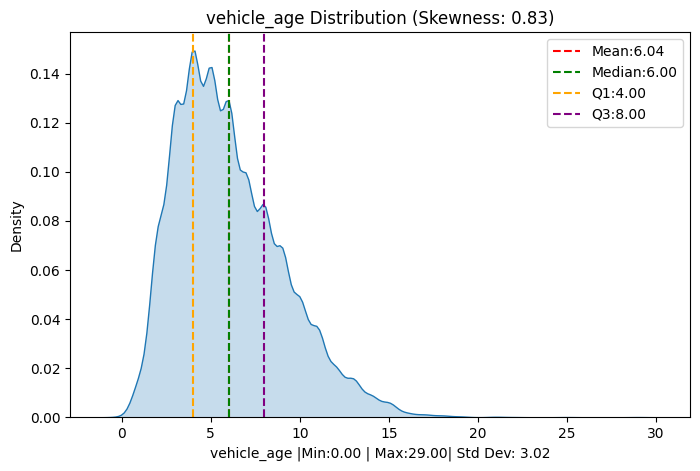

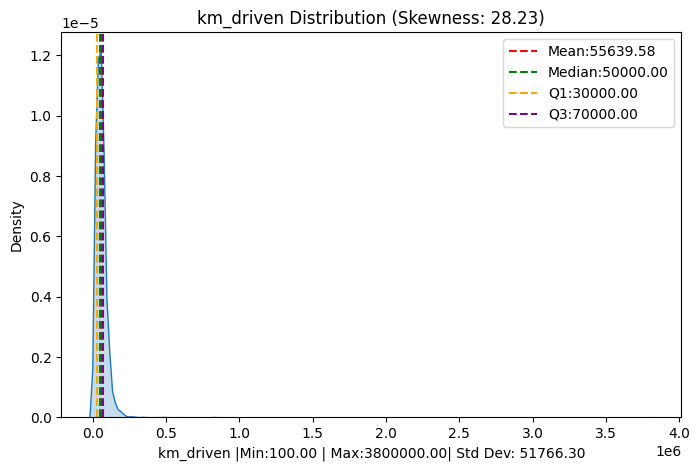

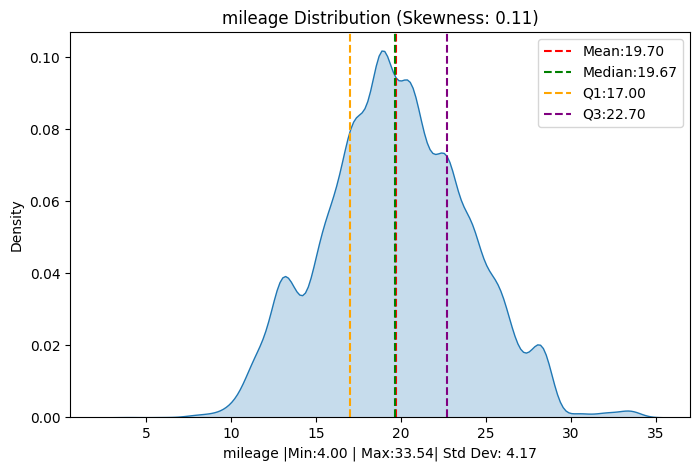

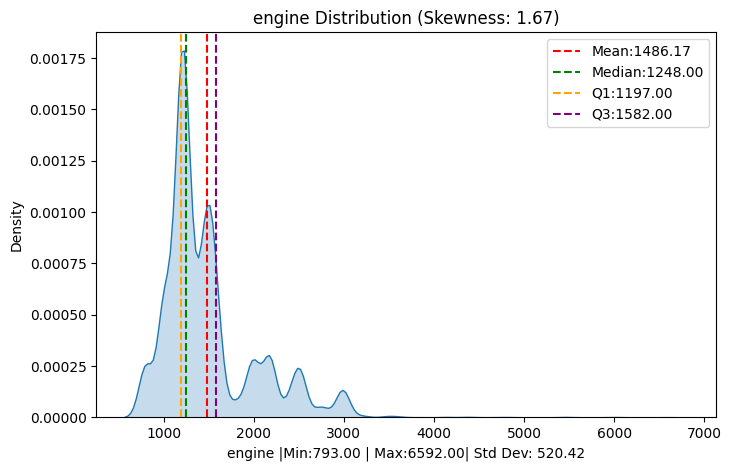

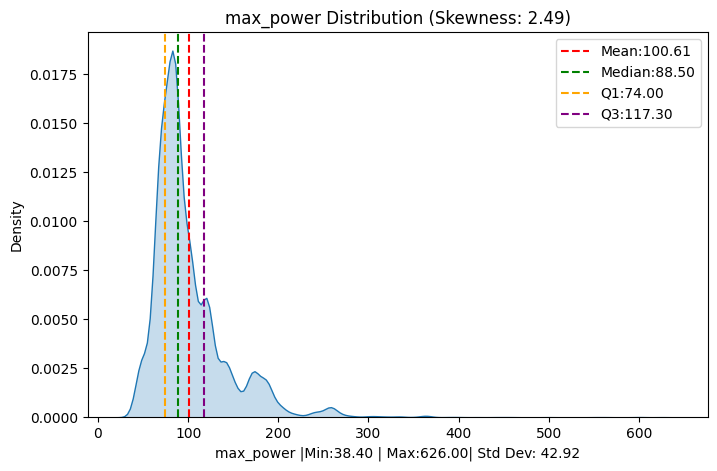

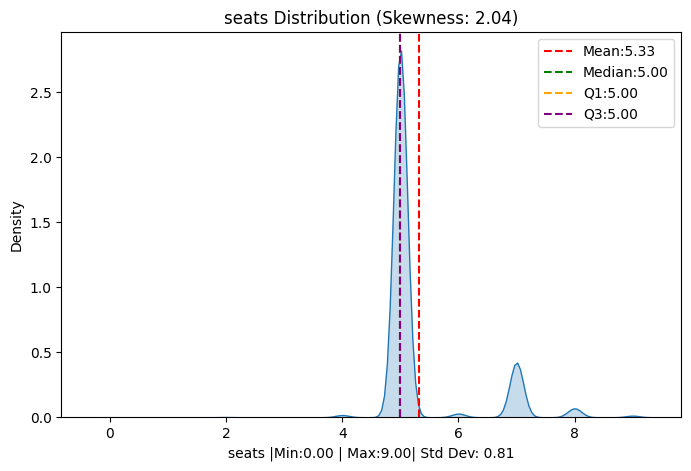

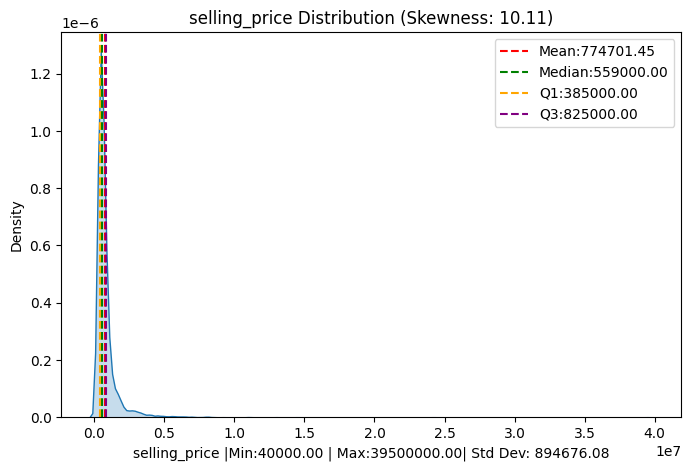

In [7]:
for feature in numerical_features:
    plt.figure(figsize=(8,5))
    sns.kdeplot(data=df[feature],fill=True)

    mean = df[feature].mean()
    median = df[feature].median()
    std = df[feature].std()
    min_val = df[feature].min()
    max_val = df[feature].max()
    q1 = df[feature].quantile(0.25)
    q3 = df[feature].quantile(0.75)
    skewness = df[feature].skew()

    plt.axvline(mean,color='red',linestyle='--',label=f"Mean:{mean:.2f}")
    plt.axvline(median,color='green',linestyle='--',label=f"Median:{median:.2f}")
    plt.axvline(q1,color='orange',linestyle='--',label=f"Q1:{q1:.2f}")
    plt.axvline(q3,color='purple',linestyle='--',label=f"Q3:{q3:.2f}")

    plt.title(f"{feature} Distribution (Skewness: {skewness:.2f})")
    plt.xlabel(f"{feature} |Min:{min_val:.2f} | Max:{max_val:.2f}| Std Dev: {std:.2f}")
    plt.legend()
    plt.show()


Observations from the Analysis:

Vehicle age shows slight positive skewness (0.83), indicating slightlymore newer cars in the dataset. But the distribution is still fairly symmetric. No further analysis is required.

Km driven has high positive skewness (28.28) indicating that there are more cars with less driven kilometers. There are some outliers in the data. Some few cars have driven more than 1 lakh kilometers. Further analysis is required to understand the distribution of km driven.

Mileage has skewness of 0.11. This indicates that the distribution is fairly symmetric. No further analysis is required.

Engine size has skewness of 1.67 , indicating that there are more cars with smaller engines. There are some outliers in the data. Some few cars have engines larger than 3000 cc. Further analysis is required to understand the distribution of engine size.

Max power has skewness of 2.49. This indicates that there are more cars with lower power. There are some outliers in the data. Some few cars have power more than 200 BHP. Further analysis is required to understand the distribution of power.

seat has skewness of 2.45, indicating that there are more 5 seater cars in the dataset.From the plot it is clear that there are large number of cars with 5 seats.
The minimum value is 0 which is not possible. Further analysis is required to understand the distribution of seats. 

price has a skewness of 10.11 which is very high. From the plot we can see that most of the cars are around 5.5 lakhs INR. There are some cars which are priced vary high greater then 1 crore INR. There is a possibility that these cars are luxury cars.
Which further suggests that the cars can be divided into different price ranges.
Further analysis is required to understand the distribution of price.

## Doing further analysis on the mentioned features.


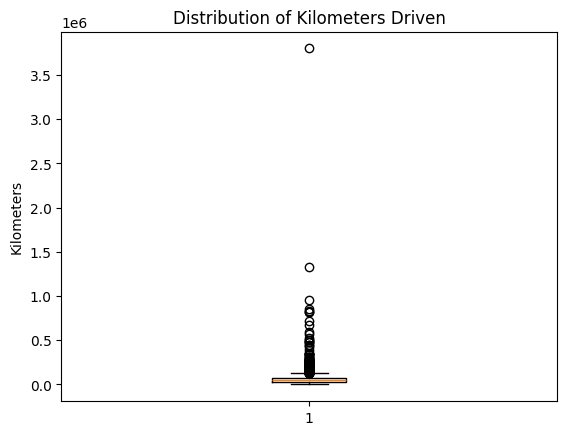

In [8]:
plt.boxplot(df['km_driven'])
plt.title('Distribution of Kilometers Driven')
plt.ylabel('Kilometers')
plt.show()

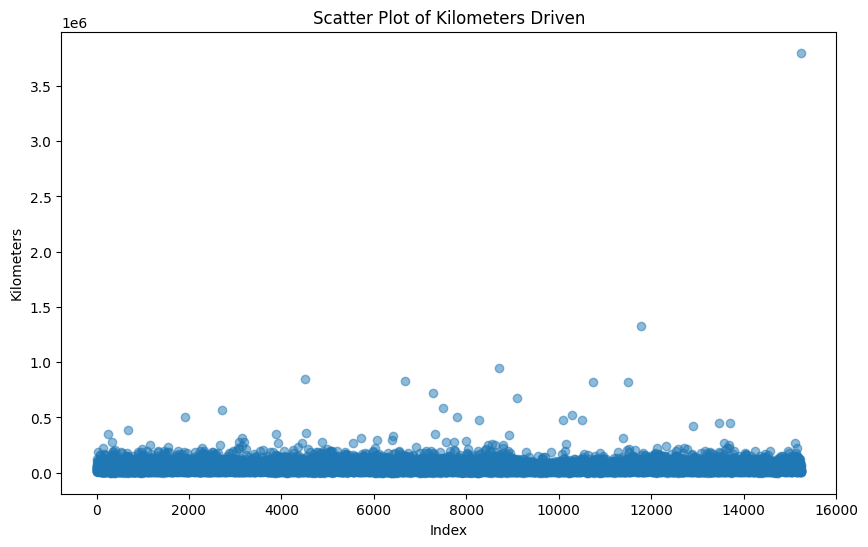

In [9]:
plt.figure(figsize=(10,6))
plt.scatter(range(len(df['km_driven'])), df['km_driven'], alpha=0.5)
plt.title('Scatter Plot of Kilometers Driven')
plt.ylabel('Kilometers')
plt.xlabel('Index')
plt.show()

In [10]:
# Find rows where km_driven > 500,000
outliers = df[df['km_driven'] > 500000]

print(f"Number of cars with km_driven > 500,000: {len(outliers)}")
# Remove outliers from the dataframe
df = df[df['km_driven'] <= 500000]
print(f"Percentage of data removed: {(len(outliers)/len(df))*100:.2f}%")


Number of cars with km_driven > 500,000: 12
Percentage of data removed: 0.08%


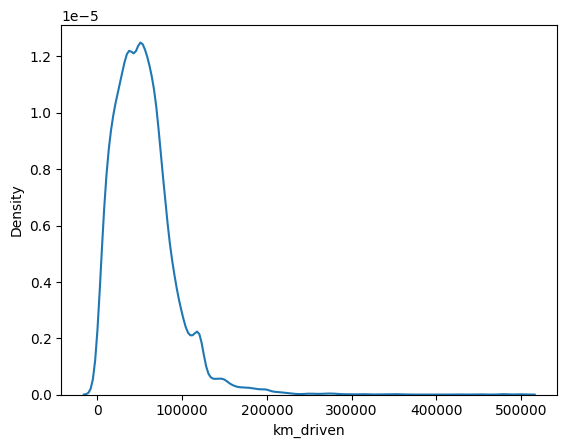

Skewness of km_driven after removing outliers: 2.25

This shows the distribution is still right-skewed but less extreme after removing outliers


In [11]:
sns.kdeplot(df['km_driven'])
plt.show()
# Calculate skewness after removing outliers
print(f"Skewness of km_driven after removing outliers: {df['km_driven'].skew():.2f}")

# Let's compare this with the original skewness
print("\nThis shows the distribution is still right-skewed but less extreme after removing outliers")







After removing only 12 outliers, the skewness of km_driven is reduced from 28.28 to 2.25. This shows that the distribution is still right-skewed but less extreme after removing outliers.


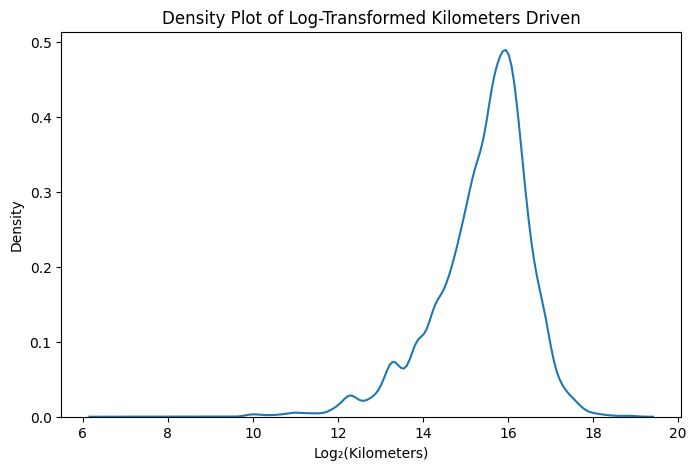

Skewness of log-transformed km_driven with base 2: -1.10


In [12]:
# Apply log transformation and plot density
plt.figure(figsize=(8,5))
sns.kdeplot(np.log2(df['km_driven']))
plt.title('Density Plot of Log-Transformed Kilometers Driven')
plt.xlabel('Log₂(Kilometers)')
plt.show()
# Calculate skewness of log transformed data
print(f"Skewness of log-transformed km_driven with base 2: {np.log2(df['km_driven']).skew():.2f}")


After applying log transformation with base 2, the skewness of km_driven is reduced from 2.25 to -1.10. This shows that the distribution is more symmetric after log transformation.


In [13]:
# Create a new column for log transformed km_driven
df['log_km_driven'] = np.log2(df['km_driven']) 


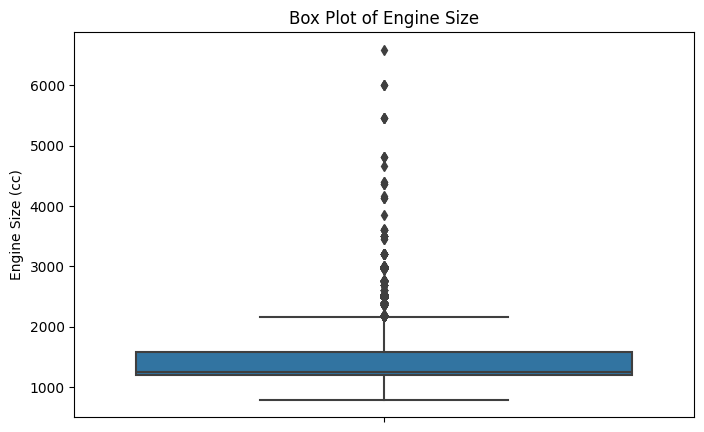


Number of outliers in engine size: 2099
Percentage of outliers: 13.78%

Outlier thresholds:
Lower bound: 619.50
Upper bound: 2159.50


In [14]:
# Create box plot for engine
plt.figure(figsize=(8,5))
sns.boxplot(y=df['engine'])
plt.title('Box Plot of Engine Size')
plt.ylabel('Engine Size (cc)')
plt.show()

# Calculate and print outlier statistics
Q1 = df['engine'].quantile(0.25)
Q3 = df['engine'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['engine'] < lower_bound) | (df['engine'] > upper_bound)]
print(f"\nNumber of outliers in engine size: {len(outliers)}")
print(f"Percentage of outliers: {(len(outliers)/len(df))*100:.2f}%")
print(f"\nOutlier thresholds:")
print(f"Lower bound: {lower_bound:.2f}")
print(f"Upper bound: {upper_bound:.2f}")


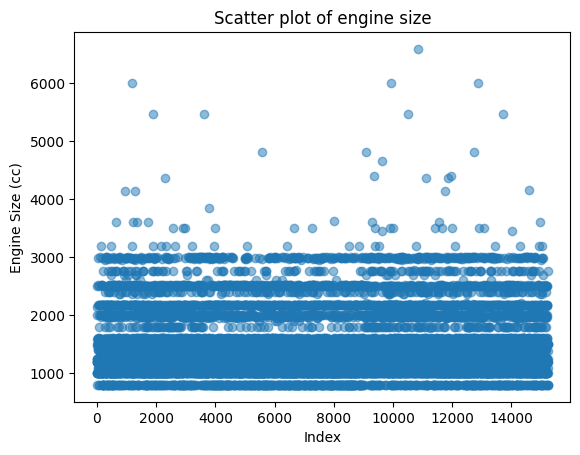

In [15]:
# Scatter plot of engine size
plt.scatter(range(len(df['engine'])), df['engine'], alpha=0.5)
plt.title('Scatter plot of engine size')
plt.ylabel('Engine Size (cc)')
plt.xlabel('Index')
plt.show()

In [16]:
# Calculate percentage of engine values > 3300
outlier_count = len(df[df['engine'] > 3300])
outlier_percentage = (outlier_count / len(df)) * 100

print(f"Number of engines > 3300cc: {outlier_count}")
print(f"Percentage of engines > 3300cc: {outlier_percentage:.2f}%")


Number of engines > 3300cc: 46
Percentage of engines > 3300cc: 0.30%


Skewness of engine after removing outliers: 1.32


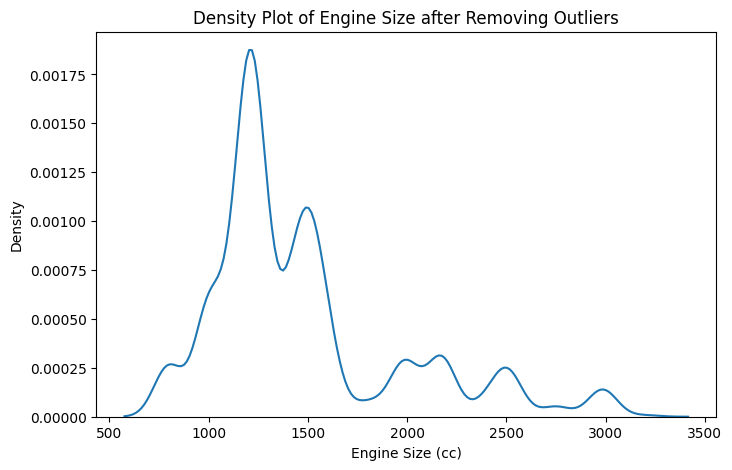

In [17]:
# Remove outliers from the dataframe
df = df[df['engine'] <= 3300]

# Calculate skewness after removing outliers
print(f"Skewness of engine after removing outliers: {df['engine'].skew():.2f}")

# Check density plot after removing outliers
plt.figure(figsize=(8,5))
sns.kdeplot(df['engine'])
plt.title('Density Plot of Engine Size after Removing Outliers')
plt.xlabel('Engine Size (cc)')
plt.show()


After removing 0.30% outliers from the engine size, the skewness of the engine size is reduced from 1.67 to 1.32 making it more symmetric.

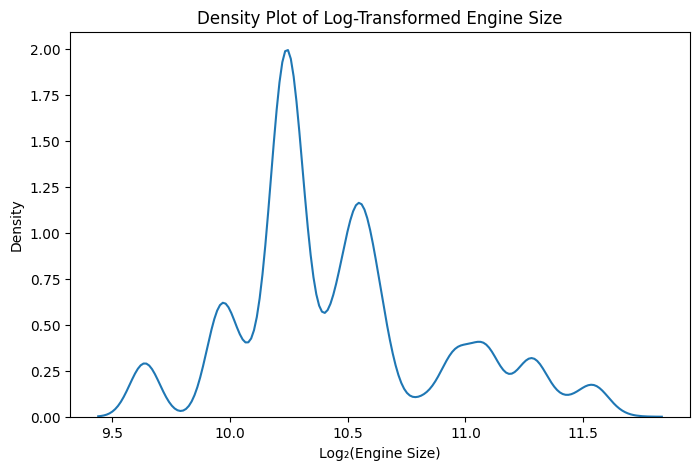

Skewness of log-transformed engine with base 2: 0.62


In [18]:
#apply log transformation to engine size
plt.figure(figsize=(8,5))
sns.kdeplot(np.log2(df['engine']))
plt.title('Density Plot of Log-Transformed Engine Size')
plt.xlabel('Log₂(Engine Size)')
plt.show()

# Calculate skewness of log transformed data
print(f"Skewness of log-transformed engine with base 2: {np.log2(df['engine']).skew():.2f}")


There is no mejor change in the skewness of the engine size after log transformation.
Also the values are not large enough to apply log transformation. Engine size does not require further processing


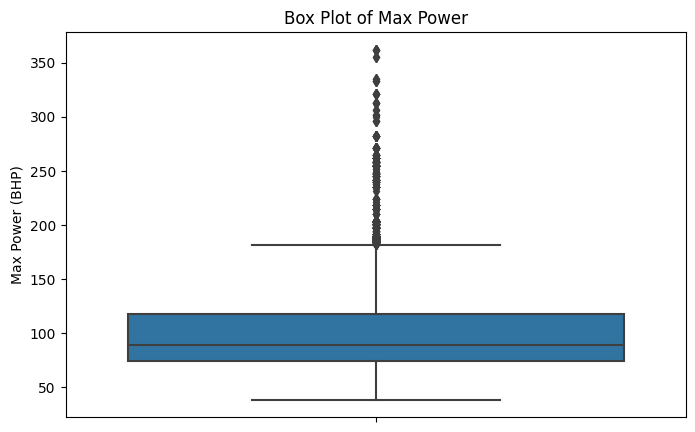


Number of outliers in max power: 806
Percentage of outliers: 5.31%


In [19]:
plt.figure(figsize=(8,5))
sns.boxplot(y=df['max_power'])
plt.title('Box Plot of Max Power')
plt.ylabel('Max Power (BHP)')
plt.show()

# Calculate and print outlier statistics
Q1 = df['max_power'].quantile(0.25)
Q3 = df['max_power'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['max_power'] < lower_bound) | (df['max_power'] > upper_bound)]
print(f"\nNumber of outliers in max power: {len(outliers)}")
print(f"Percentage of outliers: {(len(outliers)/len(df))*100:.2f}%")

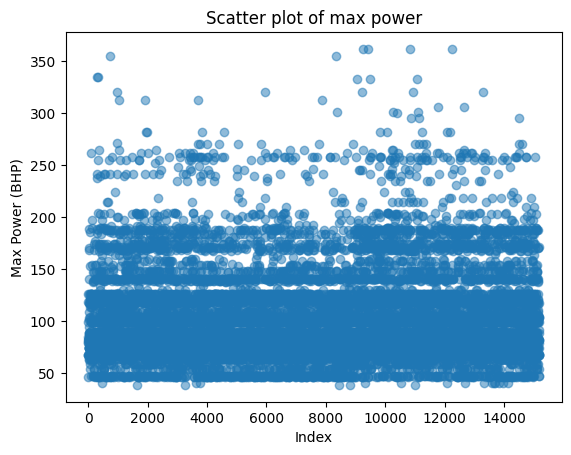

In [20]:
# apply scatter plot to max power
plt.scatter(range(len(df['max_power'])), df['max_power'], alpha=0.5)
plt.title('Scatter plot of max power')
plt.ylabel('Max Power (BHP)')
plt.xlabel('Index')
plt.show()

There are too many outliers in the max power. making it not a good idea to remove them. No further processing is required. 


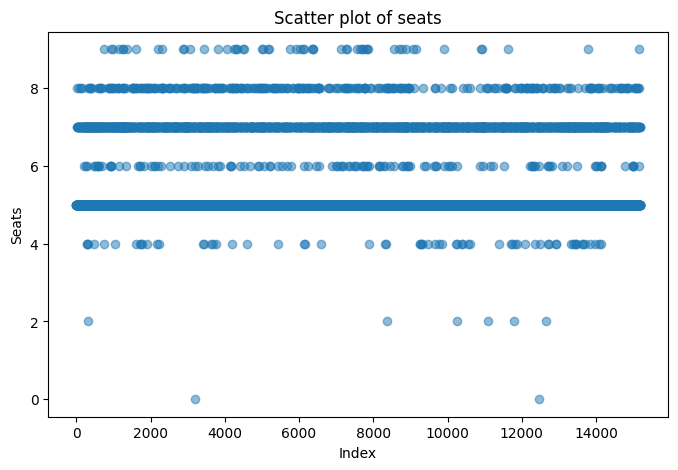

In [21]:
# apply scatter plot on seats
plt.figure(figsize=(8,5))
plt.scatter(range(len(df['seats'])), df['seats'], alpha=0.5)
plt.title('Scatter plot of seats')
plt.ylabel('Seats')
plt.xlabel('Index')
plt.show()




There are 2 values which are 0, which indicates that the car has no seats. These values are not possible and seems wrong data points. We will remove these values.


In [22]:
# remove the values which are 0 
df = df[df['seats'] != 0]


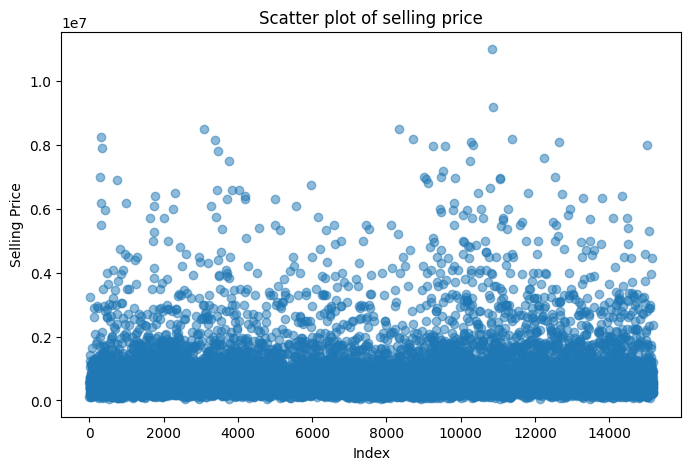

In [23]:
# apply scatterplot on price 
plt.figure(figsize=(8,5))
plt.scatter(range(len(df['selling_price'])), df['selling_price'], alpha=0.5)
plt.title('Scatter plot of selling price')
plt.ylabel('Selling Price')
plt.xlabel('Index')
plt.show()



In [24]:
df["selling_price"].max()

11000000

There are some cars which are prices very high, maybe they are luxury cars. During analysis of other features, some of the cars price values are removed. For example a 3cr car is removed. We will use car price as a target variable. 


## Univariate Analysis on Categorical Features 


In [25]:
# show me only categorical features
categorical_features = df.select_dtypes(include=['object']).columns
categorical_features


Index(['car_name', 'brand', 'model', 'seller_type', 'fuel_type',
       'transmission_type'],
      dtype='object')

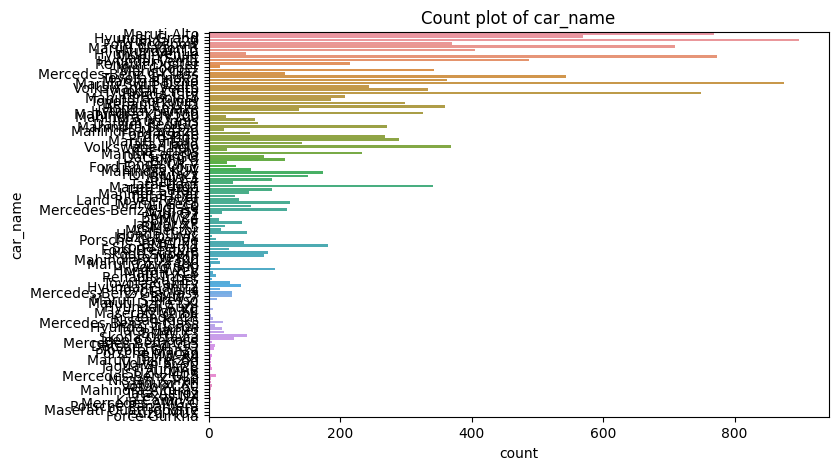

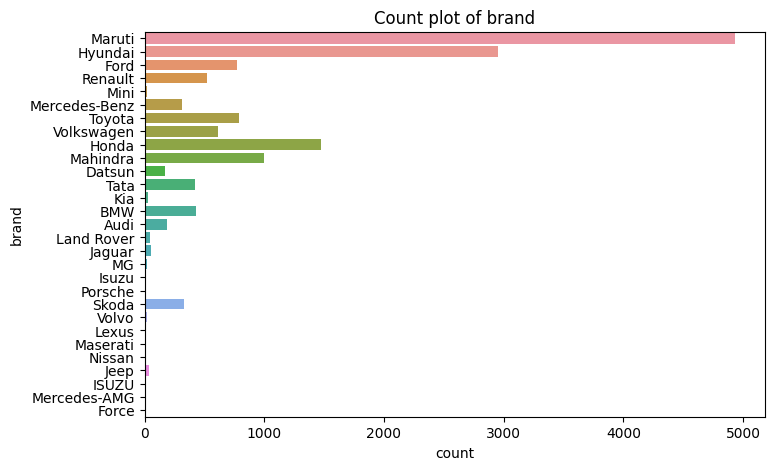

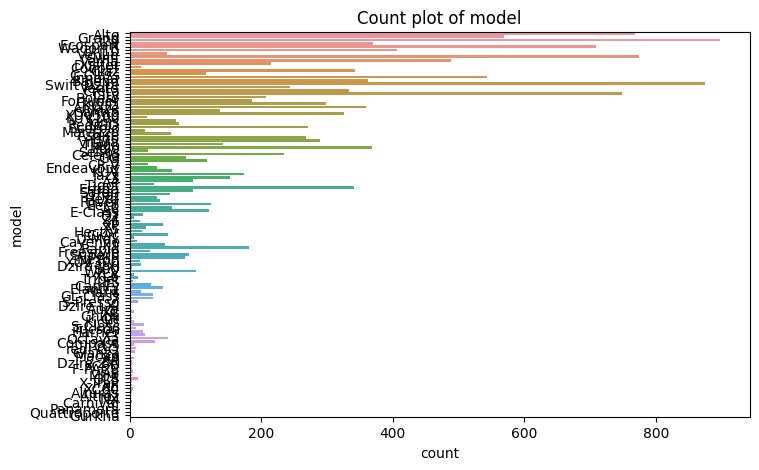

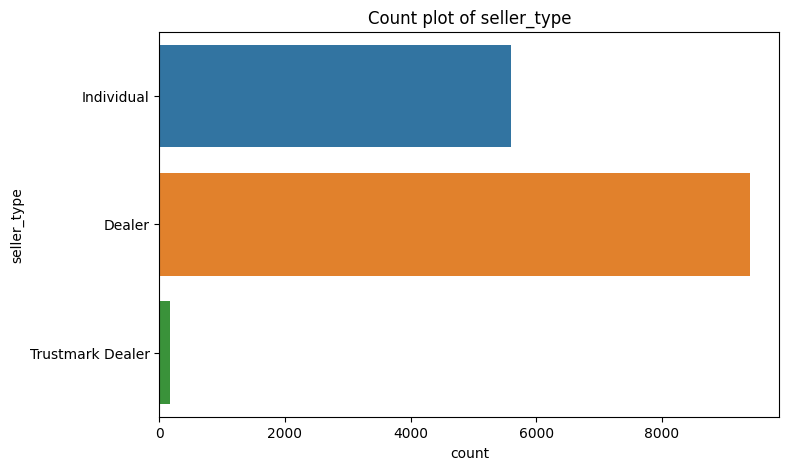

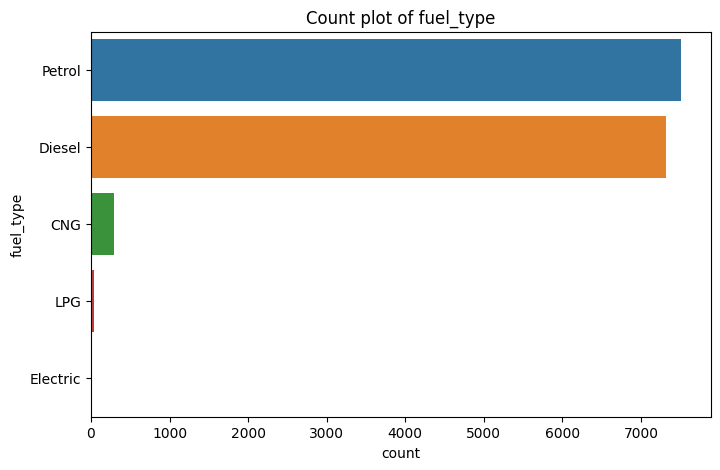

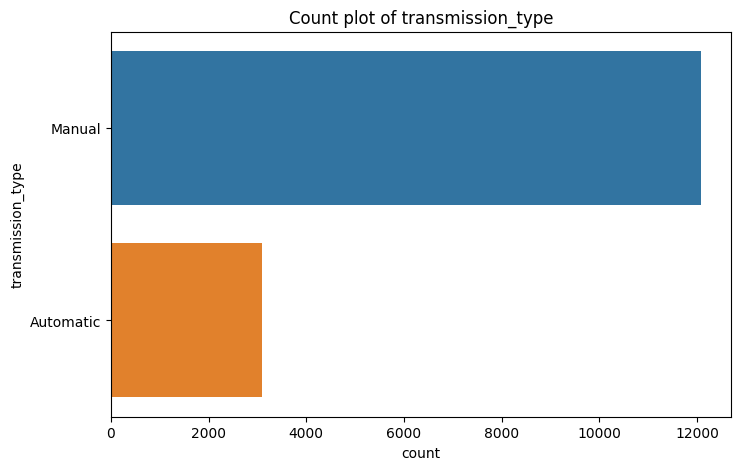

In [26]:
for feature in categorical_features:
    plt.figure(figsize=(8,5))
    sns.countplot(y=df[feature])
    plt.title(f'Count plot of {feature}')
    plt.ylabel(feature)
    plt.show()  


In [27]:
# count number of electric cars 
df[df['fuel_type'] == 'Electric'].shape[0]


4

In the dataset there are only 4 electric cars. We will remove this feature from the dataset because it will downgrade the performance of the model as there are less representation of electric cars in the dataset.


In [28]:
# Removing electric vahical 
df=df[df["fuel_type"] != "Electric"]


Try to balance the dataset by upsampling the minority classes.


In [29]:
categorical_features 

Index(['car_name', 'brand', 'model', 'seller_type', 'fuel_type',
       'transmission_type'],
      dtype='object')

In [31]:
# Get value counts of car names
car_counts = df['car_name'].value_counts()

# Get the count of most frequent car
max_count = car_counts.max()

# Calculate 25% threshold
threshold = max_count * 0.25

# Get car names that need upsampling (less than threshold)
cars_to_upsample = car_counts[car_counts < threshold].index

# Initialize empty dataframe for upsampled data
upsampled_data = pd.DataFrame()

# Add cars that don't need upsampling
upsampled_data = pd.concat([upsampled_data, df[~df['car_name'].isin(cars_to_upsample)]])

# Upsample each car with count < threshold
for car in cars_to_upsample:
    # Get data for this car
    car_data = df[df['car_name'] == car]
    
    # Upsample to threshold count
    upsampled = car_data.sample(n=int(threshold), replace=True)
    
    # Add to upsampled data
    upsampled_data = pd.concat([upsampled_data, upsampled])

# Replace original df with balanced dataset    
df = upsampled_data.reset_index(drop=True)

# Show new distribution
print("New car distribution after upsampling:")
print(df['car_name'].value_counts())



New car distribution after upsampling:
car_name
Hyundai i20           898
Maruti Swift Dzire    875
Maruti Swift          774
Maruti Alto           768
Honda City            749
                     ... 
BMW X1                224
Hyundai Venue         224
Skoda Octavia         224
Honda Civic           224
Force Gurkha          224
Name: count, Length: 116, dtype: int64


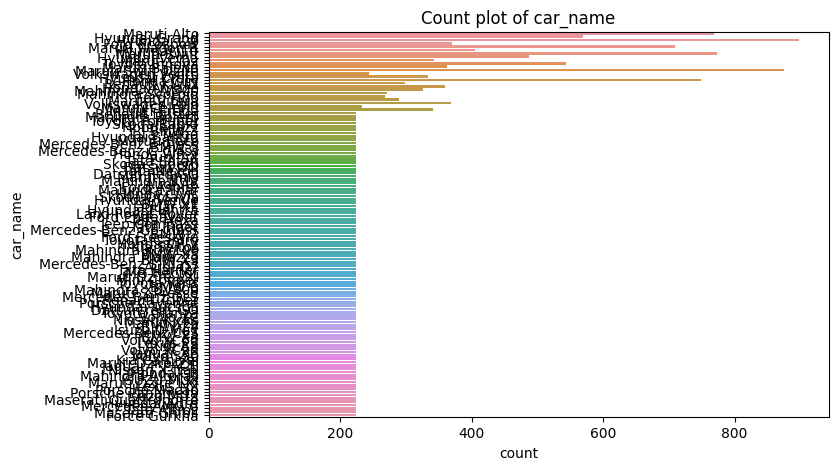

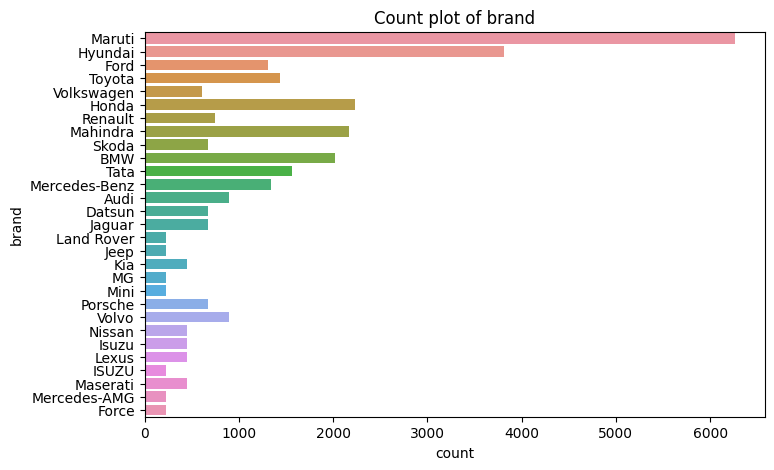

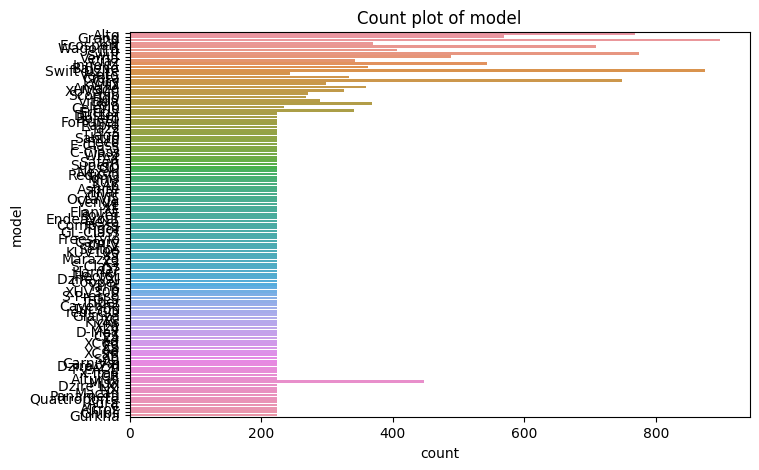

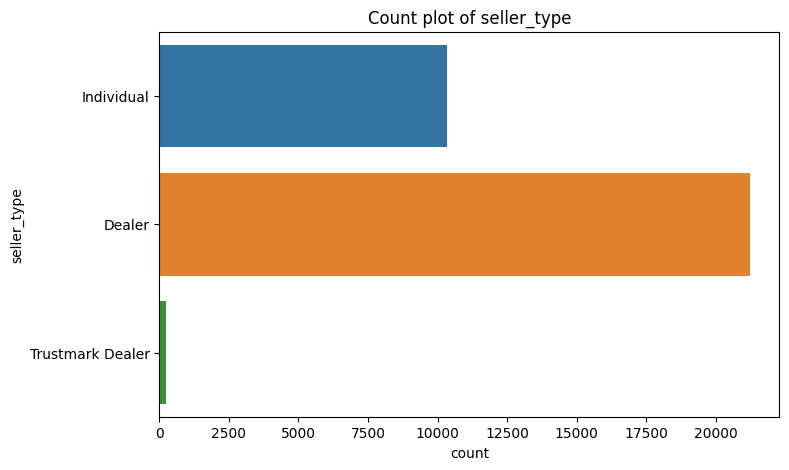

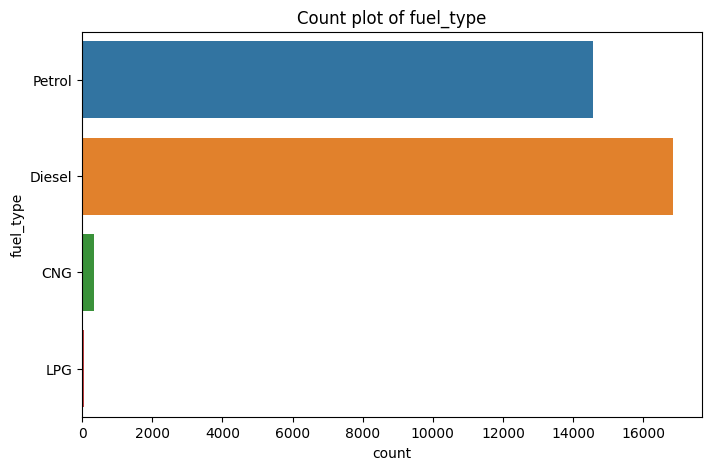

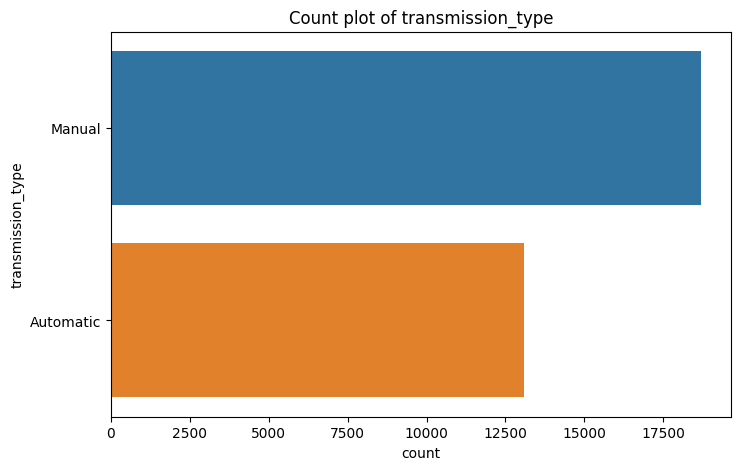

In [32]:
for feature in categorical_features:
    plt.figure(figsize=(8,5))
    sns.countplot(y=df[feature])
    plt.title(f'Count plot of {feature}')
    plt.ylabel(feature)
    plt.show()  


In [33]:
# Get fuel type counts
fuel_counts = df['fuel_type'].value_counts()

# Get max count
max_fuel_count = fuel_counts.max()

# Calculate 50% threshold
fuel_threshold = max_fuel_count * 0.50

# Get fuel types that need upsampling (CNG and LPG)
fuels_to_upsample = ['CNG', 'LPG']

# Initialize empty dataframe for upsampled data
upsampled_fuel_data = pd.DataFrame()

# Add records that don't need upsampling
upsampled_fuel_data = pd.concat([upsampled_fuel_data, df[~df['fuel_type'].isin(fuels_to_upsample)]])

# Upsample CNG and LPG
for fuel in fuels_to_upsample:
    # Get data for this fuel type
    fuel_data = df[df['fuel_type'] == fuel]
    
    # Upsample to threshold count
    upsampled = fuel_data.sample(n=int(fuel_threshold), replace=True)
    
    # Add to upsampled data
    upsampled_fuel_data = pd.concat([upsampled_fuel_data, upsampled])

# Replace original df with balanced dataset    
df = upsampled_fuel_data.reset_index(drop=True)

# Show new distribution
print("New fuel type distribution after upsampling:")
print(df['fuel_type'].value_counts())


New fuel type distribution after upsampling:
fuel_type
Diesel    16833
Petrol    14563
CNG        8416
LPG        8416
Name: count, dtype: int64


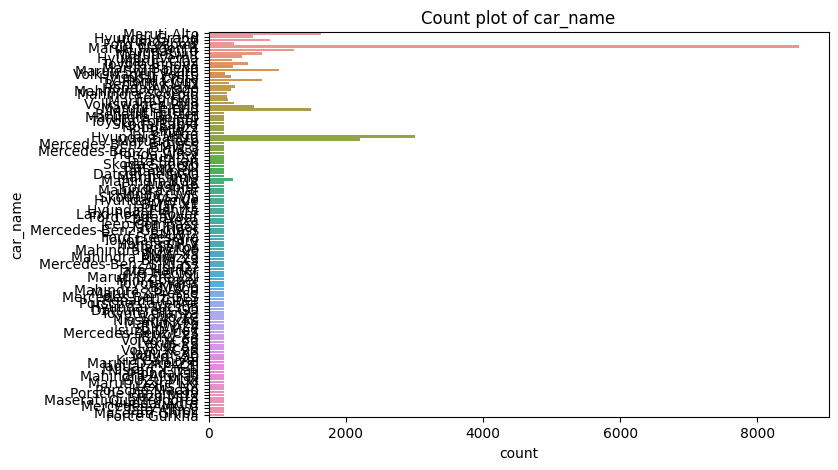

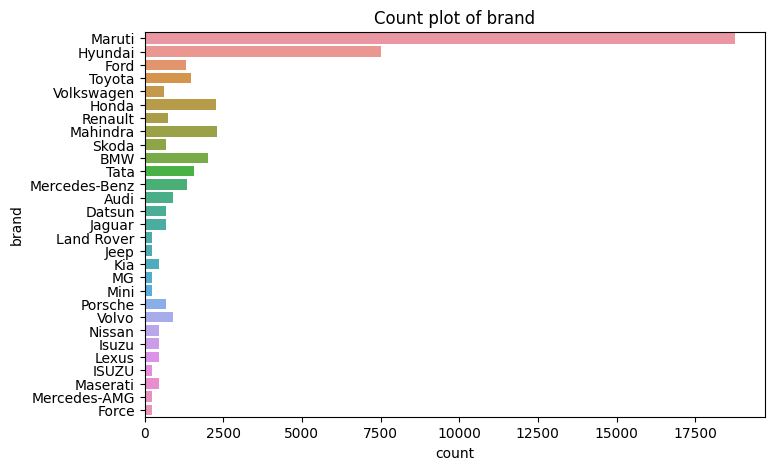

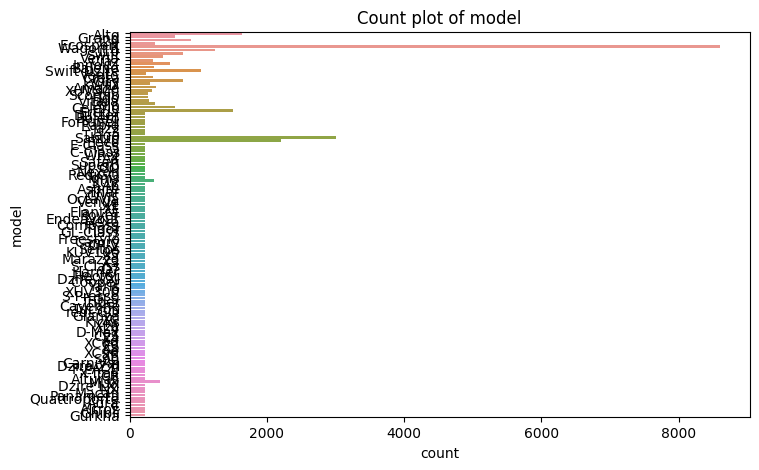

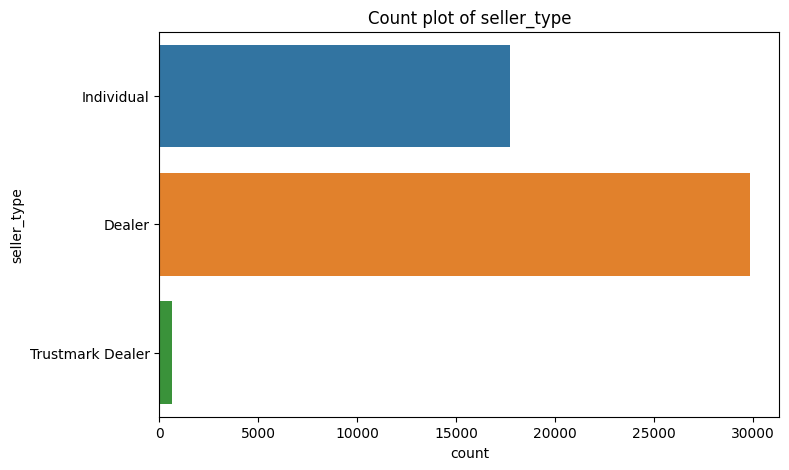

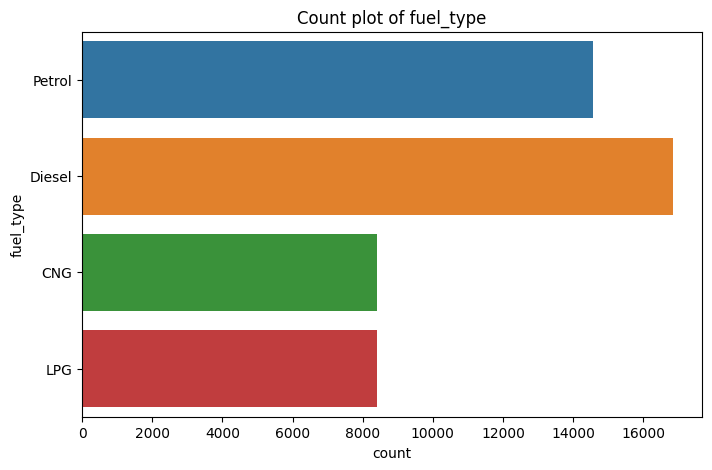

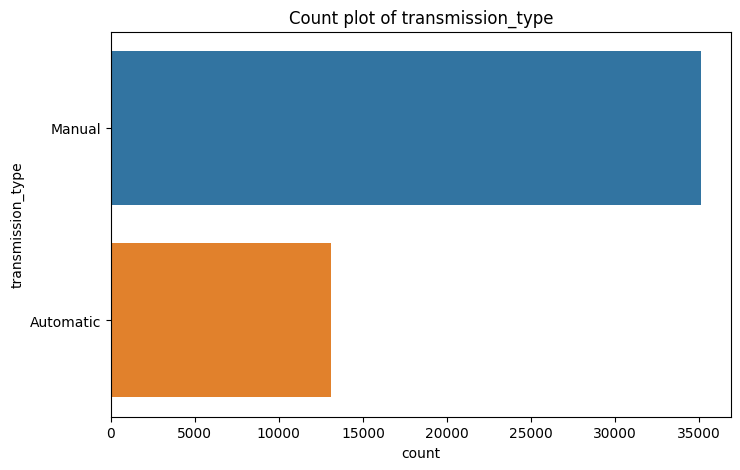

In [34]:
for feature in categorical_features:
    plt.figure(figsize=(8,5))
    sns.countplot(y=df[feature])
    plt.title(f'Count plot of {feature}')
    plt.ylabel(feature)
    plt.show()  

In [35]:
# Get seller type counts
seller_counts = df['seller_type'].value_counts()

# Get max count
max_seller_count = seller_counts.max()

# Calculate 50% threshold
seller_threshold = max_seller_count * 0.50

# Get seller types that need upsampling
sellers_to_upsample = ['Trustmark Dealer']

# Initialize empty dataframe for upsampled data
upsampled_seller_data = pd.DataFrame()

# Add records that don't need upsampling
upsampled_seller_data = pd.concat([upsampled_seller_data, df[~df['seller_type'].isin(sellers_to_upsample)]])

# Upsample Trustmark Dealer
for seller in sellers_to_upsample:
    # Get data for this seller type
    seller_data = df[df['seller_type'] == seller]
    
    # Upsample to threshold count
    upsampled = seller_data.sample(n=int(seller_threshold), replace=True)
    
    # Add to upsampled data
    upsampled_seller_data = pd.concat([upsampled_seller_data, upsampled])

# Replace original df with balanced dataset    
df = upsampled_seller_data.reset_index(drop=True)

# Show new distribution
print("New seller type distribution after upsampling:")
print(df['seller_type'].value_counts())


New seller type distribution after upsampling:
seller_type
Dealer              29853
Individual          17740
Trustmark Dealer    14926
Name: count, dtype: int64


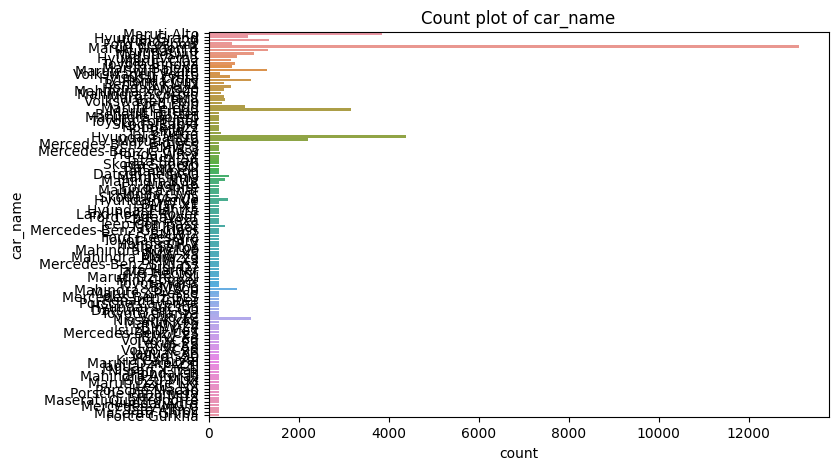

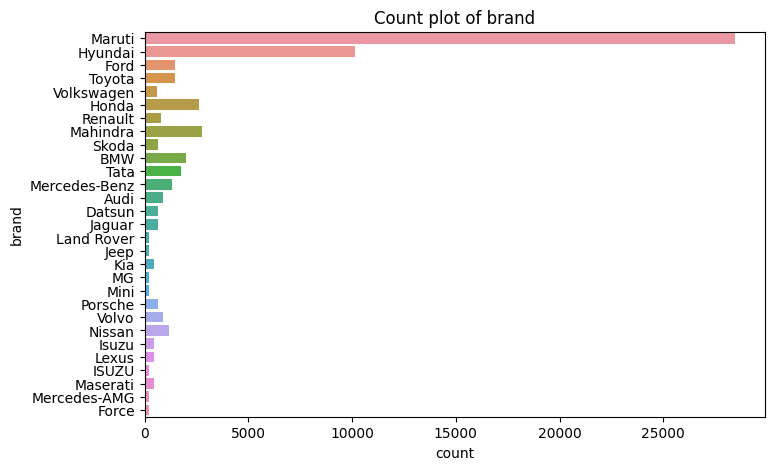

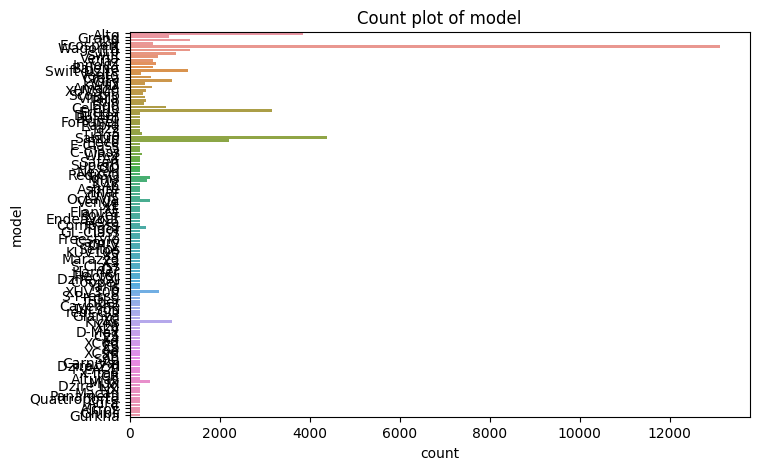

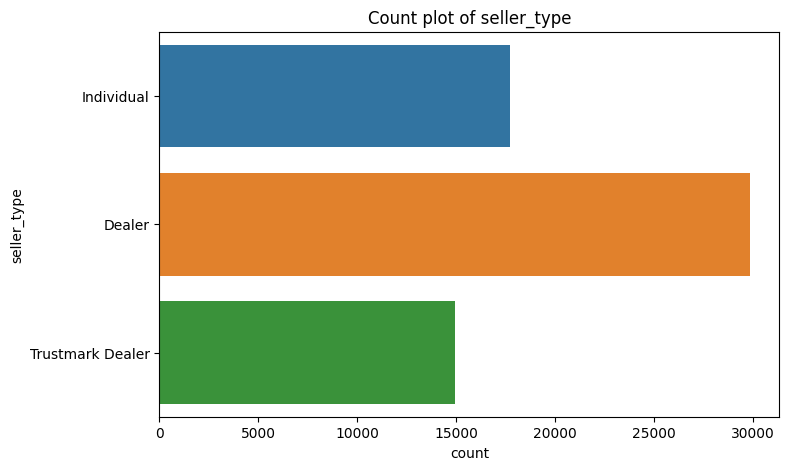

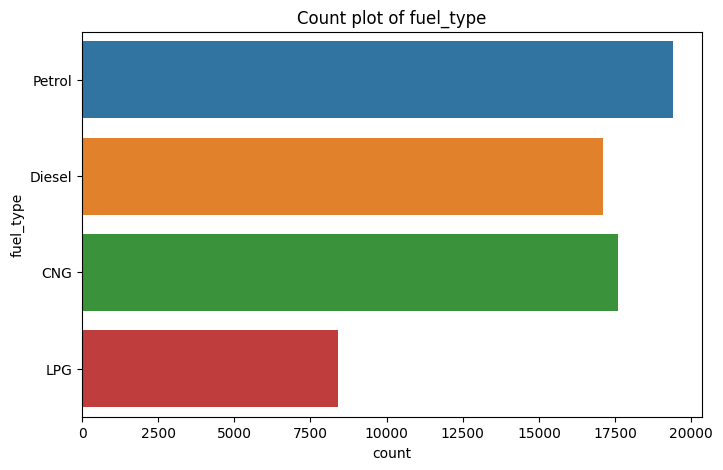

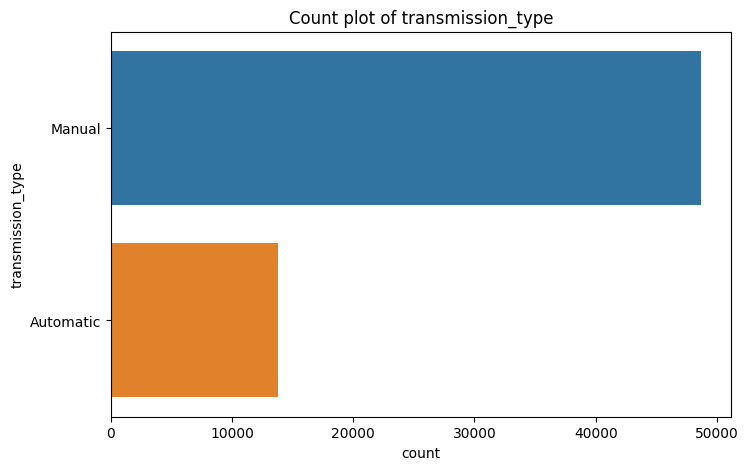

In [36]:
for feature in categorical_features:
    plt.figure(figsize=(8,5))
    sns.countplot(y=df[feature])
    plt.title(f'Count plot of {feature}')
    plt.ylabel(feature)
    plt.show()  

## Bivariate analysys

It helps us to understand how much each independent feature is related to target value (price)

In [37]:
df.columns

Index(['car_name', 'brand', 'model', 'vehicle_age', 'km_driven', 'seller_type',
       'fuel_type', 'transmission_type', 'mileage', 'engine', 'max_power',
       'seats', 'selling_price', 'log_km_driven'],
      dtype='object')

In [40]:
df=df.drop(columns=["km_driven"])

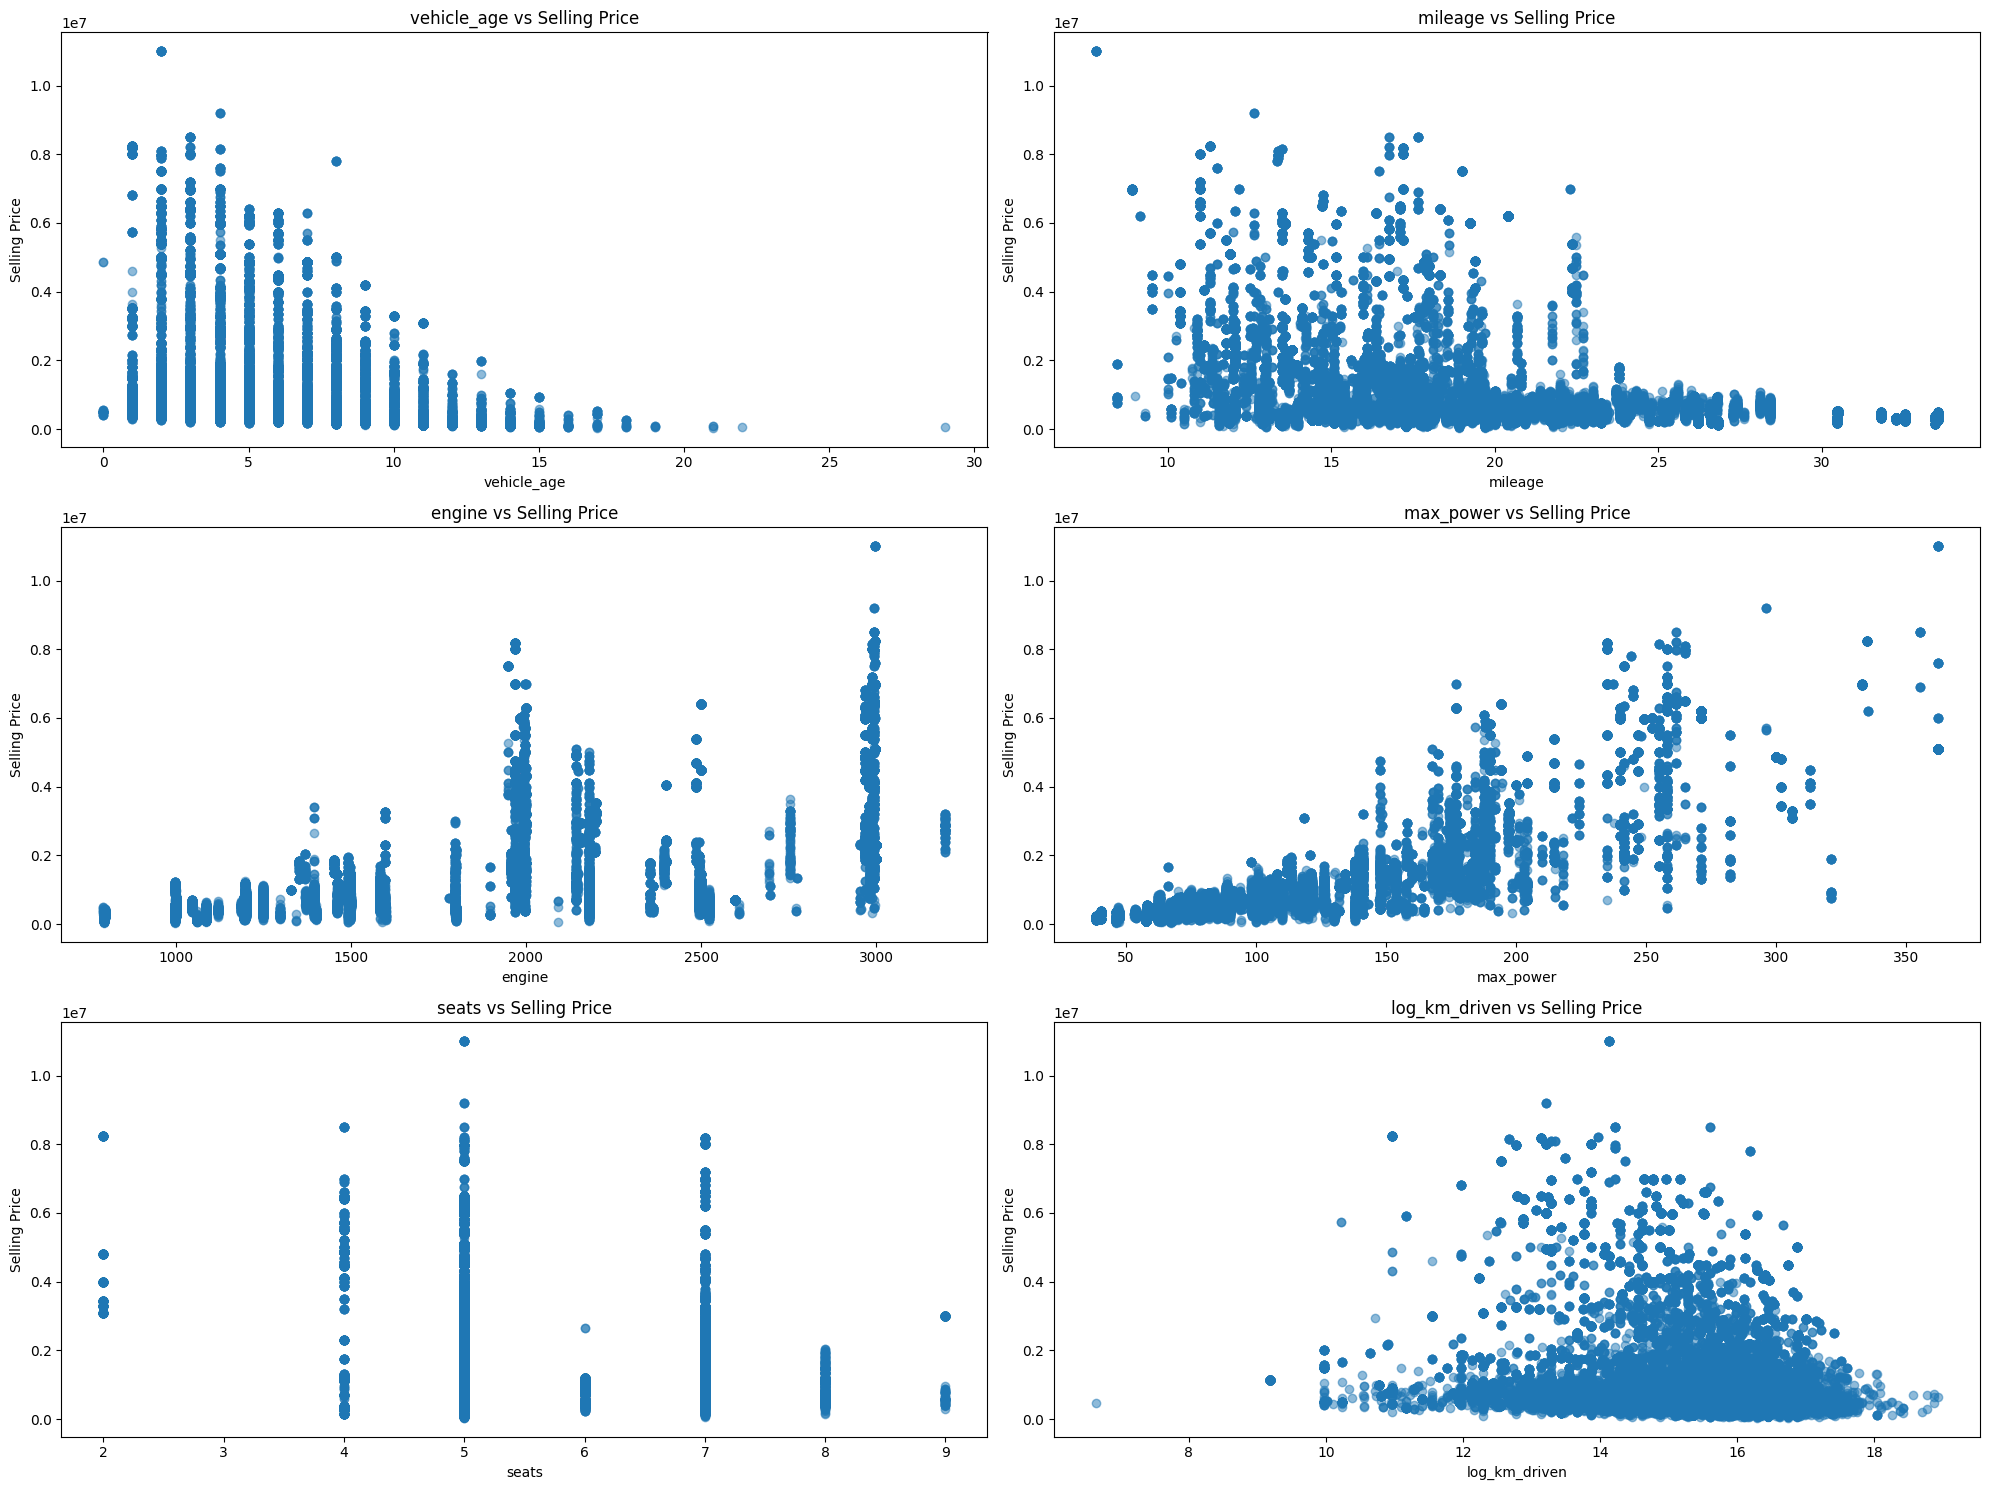

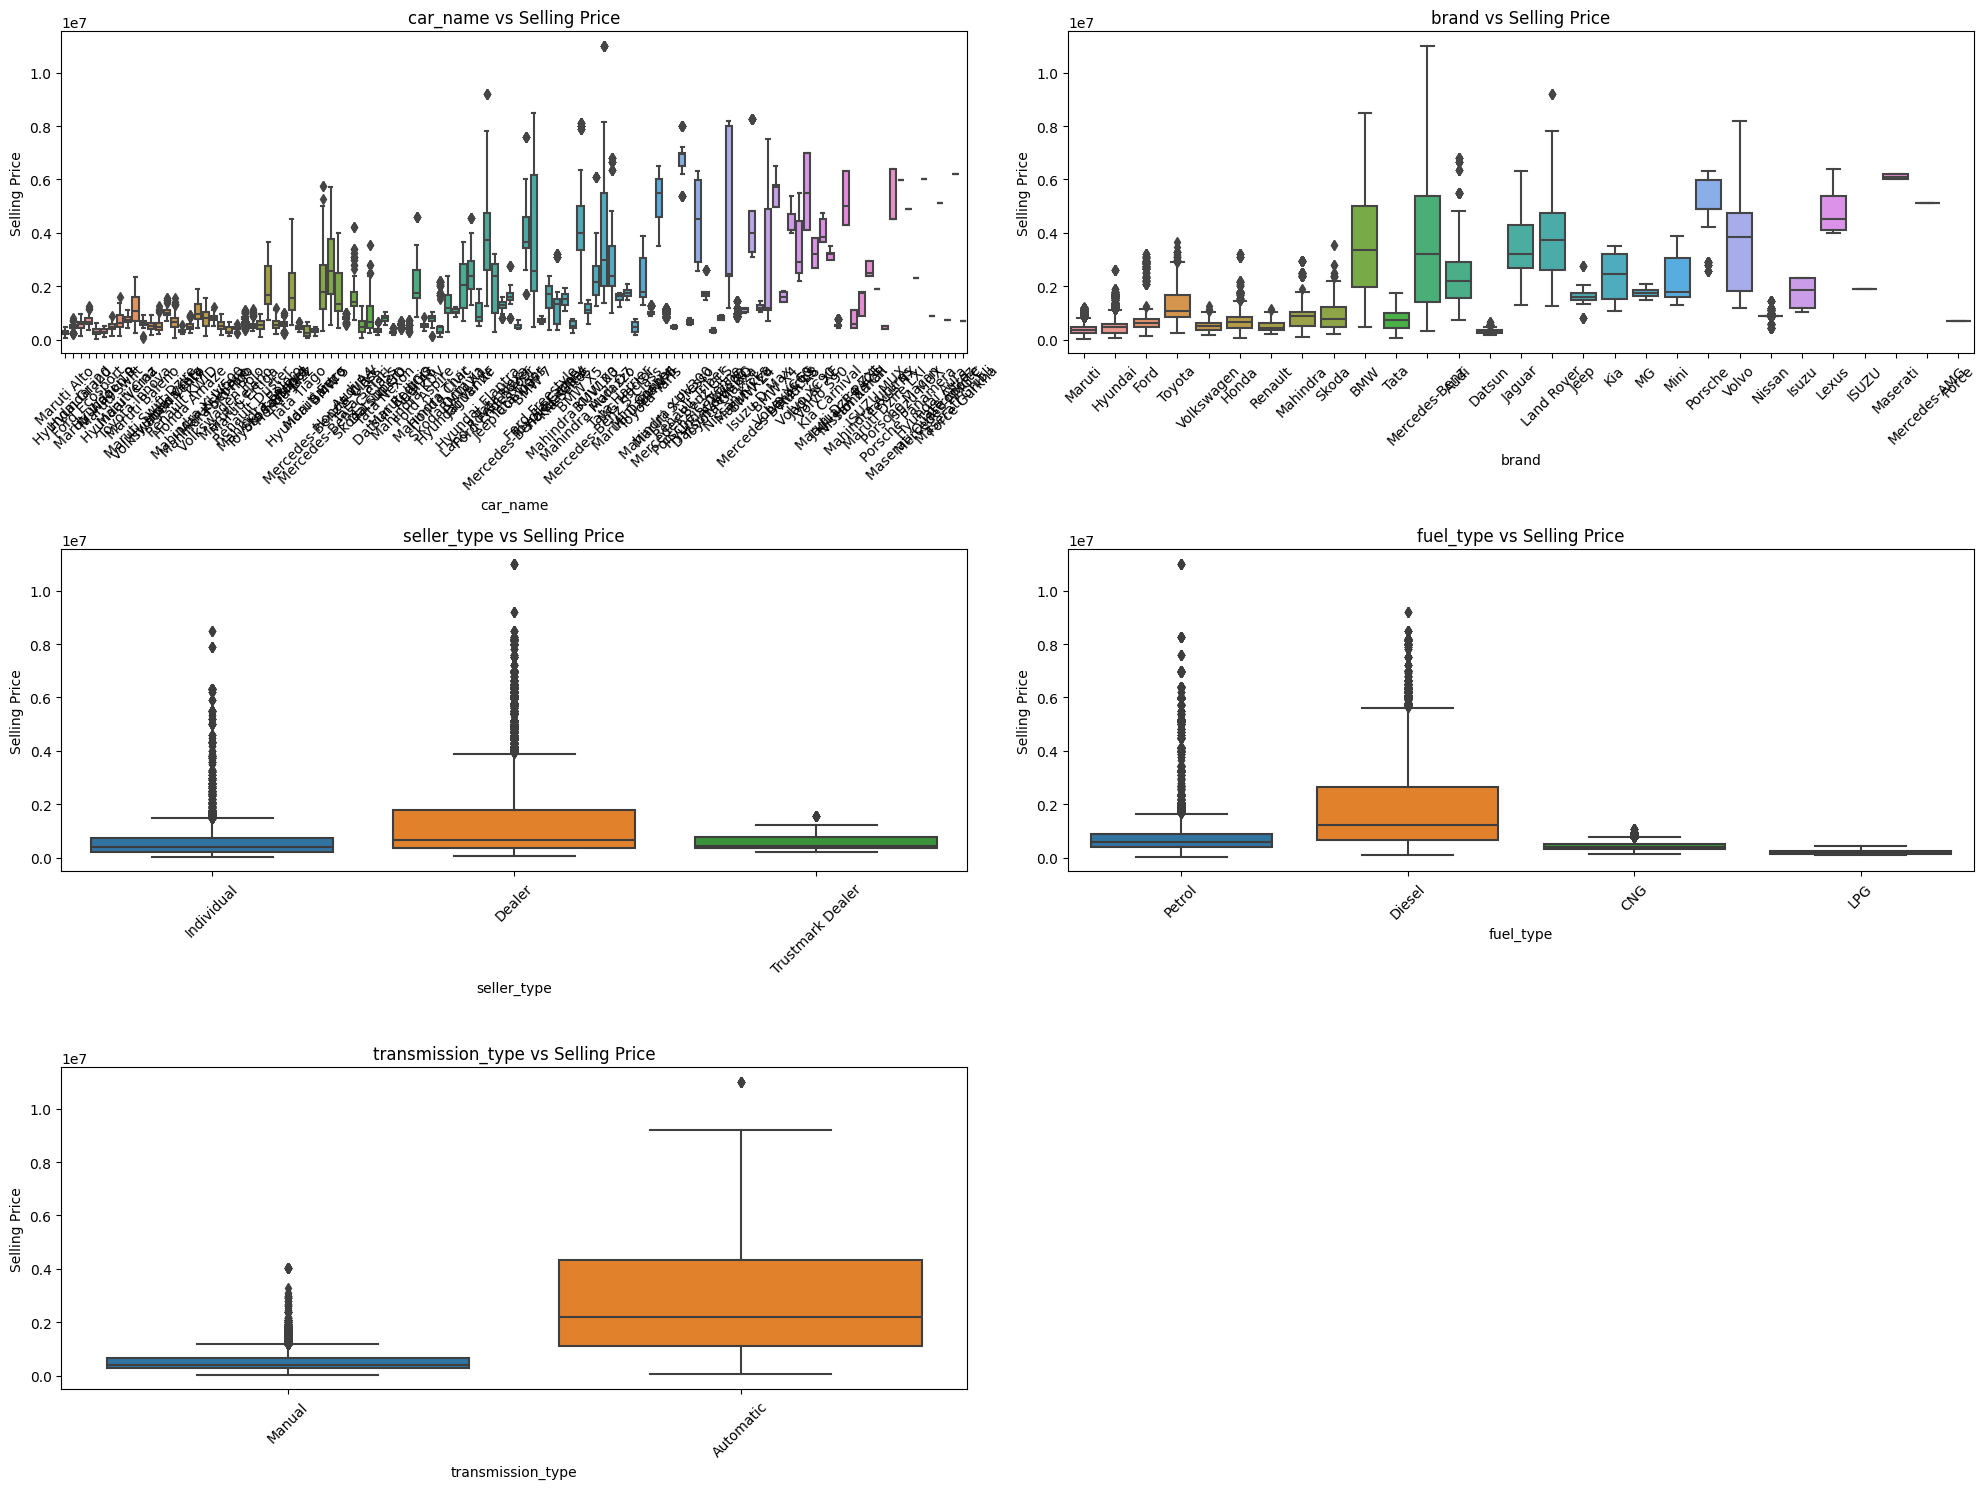

In [44]:
# Numerical features bivariate analysis
numerical_features = ['vehicle_age', 'mileage', 'engine', 'max_power', 'seats', 'log_km_driven']

plt.figure(figsize=(20,15))
for i, feature in enumerate(numerical_features, 1):
    plt.subplot(3,2,i)
    plt.scatter(df[feature], df['selling_price'], alpha=0.5)
    plt.xlabel(feature)
    plt.ylabel('Selling Price')
    plt.title(f'{feature} vs Selling Price')
plt.tight_layout()
plt.show()

# Categorical features bivariate analysis
categorical_features = ['car_name','brand', 'seller_type', 'fuel_type', 'transmission_type']

plt.figure(figsize=(20,15))
for i, feature in enumerate(categorical_features, 1):
    plt.subplot(3,2,i)  # Changed from (2,2) to (3,2) to accommodate all features
    sns.boxplot(x=df[feature], y=df['selling_price'])
    plt.xticks(rotation=45)
    plt.xlabel(feature)
    plt.ylabel('Selling Price')
    plt.title(f'{feature} vs Selling Price')
plt.tight_layout()
plt.show()

## Observations: 

1. Vehical price and age are negatively corelated as incresing the age decrease the price of car.
2. Increase in engine size increases the price of car.
3. Power of car and price of car is positively corelated.
4. There are some cars brands that has high median price. We can seperate them as luxary cars.
5. Disel cars are priced higher.
6. Automatic cars has more price then manual.

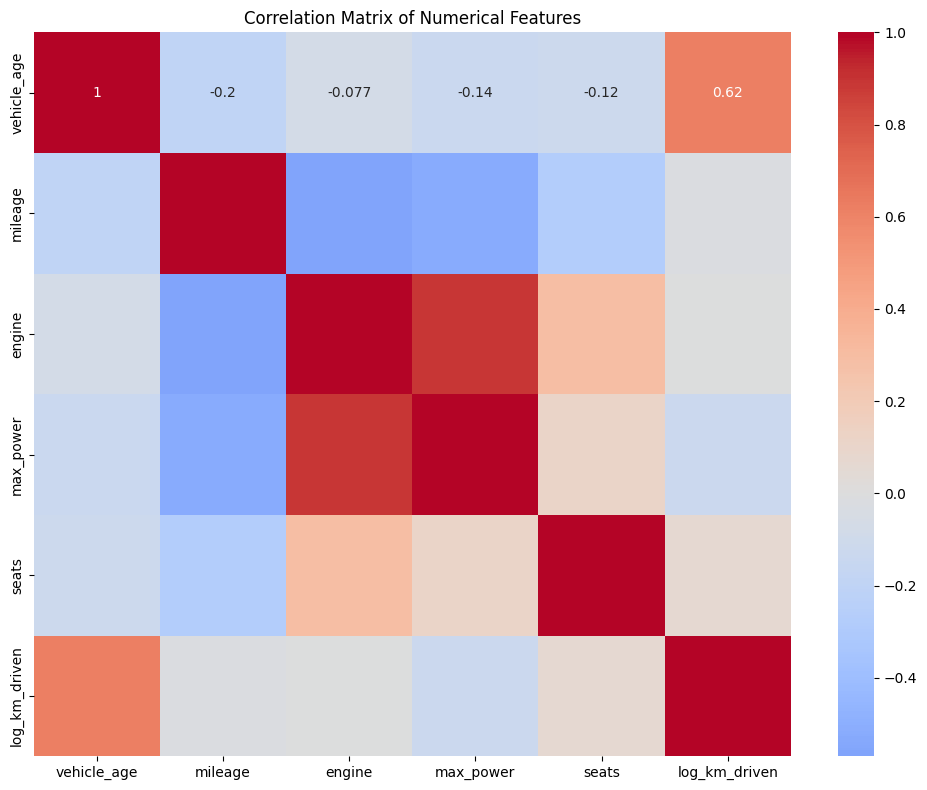

In [46]:
# Calculate correlation matrix for numerical features
numerical_features = ['vehicle_age', 'mileage', 'engine', 'max_power', 'seats', 'log_km_driven']
correlation_matrix = df[numerical_features].corr()

# Create heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Numerical Features')
plt.tight_layout()
plt.show()


## Observation 
1. engine size and max_power has high positive co-relation, which is ovious becouse heigher engine size indicates more power.
2. vehical_age and log_km_driven has high positive co-relation becouse old cars tends to be driven more.

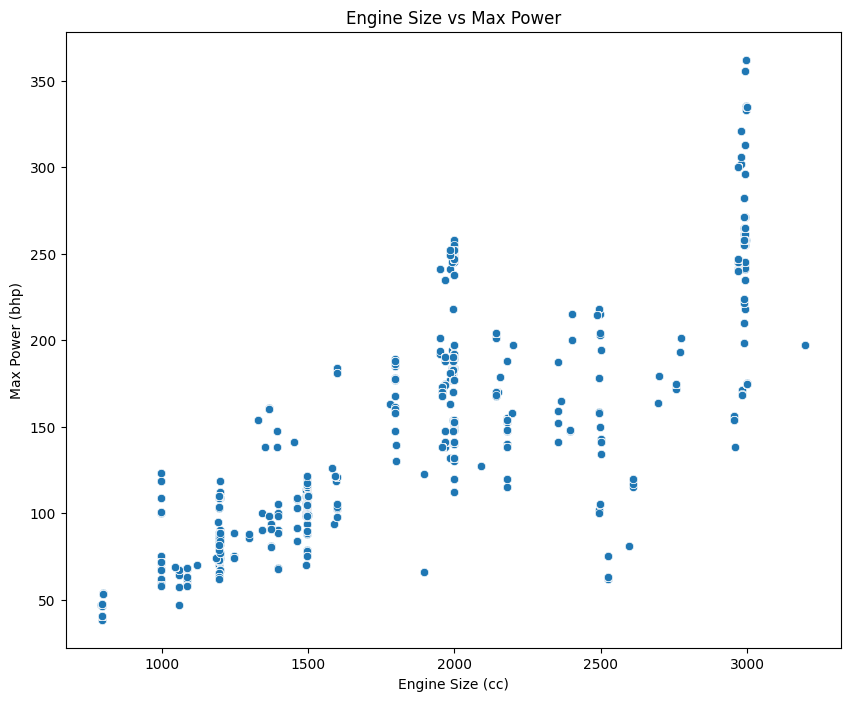

In [47]:
# Create scatter plot of max_power vs engine
plt.figure(figsize=(10,8))
sns.scatterplot(data=df, x='engine', y='max_power')
plt.title('Engine Size vs Max Power')
plt.xlabel('Engine Size (cc)')
plt.ylabel('Max Power (bhp)')
plt.show()


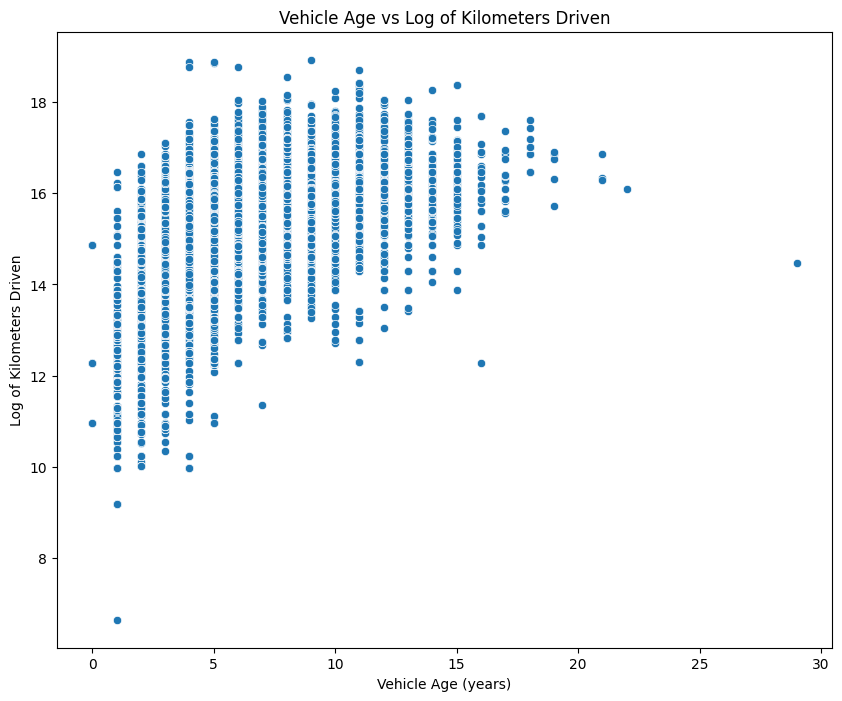

In [48]:
# Create scatter plot of vehicle age vs log_km_driven
plt.figure(figsize=(10,8))
sns.scatterplot(data=df, x='vehicle_age', y='log_km_driven')
plt.title('Vehicle Age vs Log of Kilometers Driven')
plt.xlabel('Vehicle Age (years)')
plt.ylabel('Log of Kilometers Driven')
plt.show()


The points are all over the plce there are not direct visible dependence between the features.

In [49]:
df.to_csv("car_price_preprocess.csv")

All the features are nominal ,there is no order inside the columns.
I will use binary encoding to transform the categorical variables

In [50]:
# Get categorical columns
cat_cols = df.select_dtypes(include=['object']).columns
print("Categorical columns:", cat_cols)
print("\nShape before encoding:", df.shape)

# Apply binary encoding
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

print("\nShape after encoding:", df.shape)


Categorical columns: Index(['car_name', 'brand', 'model', 'seller_type', 'fuel_type',
       'transmission_type'],
      dtype='object')

Shape before encoding: (62519, 13)

Shape after encoding: (62519, 13)


In [52]:
df.to_csv("binary_encoding_preprocessed.csv")